In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


In [2]:
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


In [3]:
MSM_LAG_NS = 50
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 50
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj



for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)
    print(f"Submodel for {name} has {submodel.n_states} microstates.")
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

MSM lag time in frames: 250
Submodel for tica_distances has 50 microstates.
Submodel for pca_distances has 21 microstates.
Submodel for tica_dihedrals has 49 microstates.
Submodel for pca_dihedrals has 50 microstates.


In [4]:

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram


def _aggregate_transition_matrix(P, pi, clusters):
    """
    Stationary-flux coarse graining of a transition matrix.

    Parameters
    ----------
    P : (n, n) ndarray
        Microstate transition matrix.
    pi : (n,) ndarray
        Stationary distribution.
    clusters : list[set[int]]
        Current aggregation of microstates.

    Returns
    -------
    T : (m, m) ndarray
        Transition matrix between current aggregates.
    populations : (m,) ndarray
        Stationary populations of the aggregates.
    """
    n_clusters = len(clusters)

    populations = np.array([
        pi[list(cluster)].sum()
        for cluster in clusters
    ])

    T = np.zeros((n_clusters, n_clusters), dtype=float)

    for a, cluster_a in enumerate(clusters):
        idx_a = np.asarray(sorted(cluster_a), dtype=int)

        if populations[a] <= 0:
            continue

        for b, cluster_b in enumerate(clusters):
            idx_b = np.asarray(sorted(cluster_b), dtype=int)

            # Equilibrium probability flux from aggregate A to aggregate B
            flux_ab = np.sum(
                pi[idx_a, None] * P[np.ix_(idx_a, idx_b)]
            )

            T[a, b] = flux_ab / populations[a]

    return T, populations


def metastability_agglomeration(
    msm,
    threshold=0.90,
    merge_rule="outgoing_probability",
    continue_to_one_cluster=True,
):
    """
    Agglomeratively merge the least metastable aggregate.

    The metastability of aggregate A is Q(A) = P(A -> A).

    Parameters
    ----------
    msm
        Deeptime MSM object with:
          - transition_matrix
          - stationary_distribution

    threshold : float
        Aggregates are considered insufficiently metastable when
        the current minimum Q is below this value.

    merge_rule : {"outgoing_probability", "symmetric_probability",
                  "equilibrium_flux"}
        Criterion used to choose the merge partner.

        outgoing_probability:
            Merge A with the B maximizing P(A -> B).

        symmetric_probability:
            Merge A with the B maximizing
            P(A -> B) + P(B -> A).

        equilibrium_flux:
            Merge A with the B having the largest stationary
            inter-aggregate flux.

    continue_to_one_cluster : bool
        If True, construct the complete hierarchy for plotting.
        The partition at `threshold` is still returned separately.

        If False, stop as soon as all remaining aggregates have
        metastability >= threshold.

    Returns
    -------
    result : dict
        Dictionary containing:
          linkage             scipy-compatible linkage matrix
          history             information about each merge
          threshold_clusters  partition obtained at the threshold
          final_clusters      clusters at termination
    """
    P = np.asarray(msm.transition_matrix, dtype=float)
    pi = np.asarray(msm.stationary_distribution, dtype=float)

    if P.ndim != 2 or P.shape[0] != P.shape[1]:
        raise ValueError("transition_matrix must be square.")

    n_states = P.shape[0]

    if pi.shape != (n_states,):
        raise ValueError(
            "stationary_distribution has an incompatible shape."
        )

    if not np.allclose(P.sum(axis=1), 1.0, atol=1e-8):
        raise ValueError("Rows of the transition matrix must sum to one.")

    if merge_rule not in {
        "outgoing_probability",
        "symmetric_probability",
        "equilibrium_flux",
    }:
        raise ValueError(f"Unknown merge_rule: {merge_rule}")

    # Physical microstate membership of each active cluster
    clusters = [{i} for i in range(n_states)]

    # Node IDs used by scipy's linkage representation
    node_ids = list(range(n_states))

    # Number of original microstates below every active tree node
    node_sizes = {i: 1 for i in range(n_states)}

    linkage_rows = []
    history = []

    threshold_clusters = None
    threshold_recorded = False

    while len(clusters) > 1:
        T, populations = _aggregate_transition_matrix(P, pi, clusters)

        metastabilities = np.diag(T)
        least_index = int(np.argmin(metastabilities))
        q_min = float(metastabilities[least_index])

        # This is the partition obtained after all merges with q_min < threshold.
        if q_min >= threshold and not threshold_recorded:
            threshold_clusters = [set(c) for c in clusters]
            threshold_recorded = True

            if not continue_to_one_cluster:
                break

        scores = np.full(len(clusters), -np.inf, dtype=float)

        for partner_index in range(len(clusters)):
            if partner_index == least_index:
                continue

            if merge_rule == "outgoing_probability":
                # Most probable destination when leaving the
                # least-metastable aggregate
                scores[partner_index] = T[least_index, partner_index]

            elif merge_rule == "symmetric_probability":
                scores[partner_index] = (
                    T[least_index, partner_index]
                    + T[partner_index, least_index]
                )

            elif merge_rule == "equilibrium_flux":
                # For a reversible model these two fluxes are equal,
                # apart from numerical error.
                flux_ab = (
                    populations[least_index]
                    * T[least_index, partner_index]
                )
                flux_ba = (
                    populations[partner_index]
                    * T[partner_index, least_index]
                )
                scores[partner_index] = flux_ab + flux_ba

        partner_index = int(np.argmax(scores))

        # Keep linkage children in a stable order
        child_1 = node_ids[least_index]
        child_2 = node_ids[partner_index]

        if child_1 > child_2:
            child_1, child_2 = child_2, child_1

        new_node_size = (
            node_sizes[node_ids[least_index]]
            + node_sizes[node_ids[partner_index]]
        )

        linkage_rows.append([
            child_1,
            child_2,
            q_min,
            new_node_size,
        ])

        merged_members = (
            clusters[least_index] | clusters[partner_index]
        )

        history.append({
            "step": len(history),
            "q_min": q_min,
            "least_metastable_cluster":
                sorted(clusters[least_index]),
            "merge_partner":
                sorted(clusters[partner_index]),
            "merged_cluster":
                sorted(merged_members),
            "merge_score":
                float(scores[partner_index]),
            "n_clusters_before":
                len(clusters),
        })

        new_node_id = n_states + len(linkage_rows) - 1
        node_sizes[new_node_id] = new_node_size

        # Delete in reverse order to avoid index shifts
        remove_indices = sorted(
            [least_index, partner_index],
            reverse=True,
        )

        for index in remove_indices:
            del clusters[index]
            del node_ids[index]

        clusters.append(merged_members)
        node_ids.append(new_node_id)

    if threshold_clusters is None:
        # The threshold was never reached; all performed merges were below it.
        threshold_clusters = [set(c) for c in clusters]

    linkage_matrix = np.asarray(linkage_rows, dtype=float)

    if linkage_matrix.size == 0:
        linkage_matrix = np.empty((0, 4), dtype=float)

    return {
        "linkage": linkage_matrix,
        "history": history,
        "threshold_clusters": [
            sorted(cluster) for cluster in threshold_clusters
        ],
        "final_clusters": [
            sorted(cluster) for cluster in clusters
        ],
        "threshold": threshold,
        "merge_rule": merge_rule,
    }

In [5]:
metastability_trees = {}

Q_THRESHOLD = 0.90

for name in trajectories_labels:
    result = metastability_agglomeration(
        msm_dict[name],
        threshold=Q_THRESHOLD,
        merge_rule="outgoing_probability",
        continue_to_one_cluster=True,
    )

    metastability_trees[name] = result

    print(f"\n{name}")
    print(
        f"Number of aggregates at Q >= {Q_THRESHOLD}: "
        f"{len(result['threshold_clusters'])}"
    )
    print("Aggregates:")
    for cluster in result["threshold_clusters"]:
        print(cluster)


tica_distances
Number of aggregates at Q >= 0.9: 2
Aggregates:
[0, 6, 12, 15, 25, 31, 38, 39]
[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

pca_distances
Number of aggregates at Q >= 0.9: 2
Aggregates:
[1, 2, 11, 19, 20]
[0, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18]

tica_dihedrals
Number of aggregates at Q >= 0.9: 2
Aggregates:
[1, 2, 3, 4, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
[0, 5, 8, 11, 24, 30, 34]

pca_dihedrals
Number of aggregates at Q >= 0.9: 2
Aggregates:
[2, 3, 4, 5, 7, 10, 11, 13, 16, 17, 19, 20, 22, 23, 24, 26, 28, 29, 30, 32, 34, 37, 41, 42, 43, 45, 46, 48, 49]
[0, 1, 6, 8, 9, 12, 14, 15, 18, 21, 25, 27, 31, 33, 35, 36, 38, 39, 40, 44, 47]


In [6]:
def plot_metastability_dendrogram(
    result,
    labels=None,
    threshold=None,
    ax=None,
    linewidth=1.2,
):
    linkage_matrix = result["linkage"]

    if linkage_matrix.shape[0] == 0:
        raise ValueError("No merges are available to plot.")

    n_leaves = linkage_matrix.shape[0] + 1

    if labels is None:
        labels = [str(i) for i in range(n_leaves)]

    if threshold is None:
        threshold = result["threshold"]

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(max(10, 0.22 * n_leaves), 5)
        )

    dendrogram(
        linkage_matrix,
        labels=labels,
        leaf_rotation=90,
        leaf_font_size=7,
        color_threshold=threshold,
        above_threshold_color="black",
        ax=ax,
    )

    # Make the tree less heavy than scipy's default
    for collection in ax.collections:
        collection.set_linewidth(linewidth)

    ax.axhline(
        threshold,
        linestyle="--",
        linewidth=1,
        label=fr"$Q_\mathrm{{threshold}}={threshold:.2f}$",
    )

    ax.set_xlabel("Microstates")
    ax.set_ylabel(
        r"Minimum aggregate metastability $Q_{\min}$"
    )
    ax.set_ylim(
        max(0, linkage_matrix[:, 2].min() - 0.03),
        min(1.01, max(threshold + 0.03,
                      linkage_matrix[:, 2].max() + 0.03)),
    )
    ax.legend(frameon=False)

    return ax

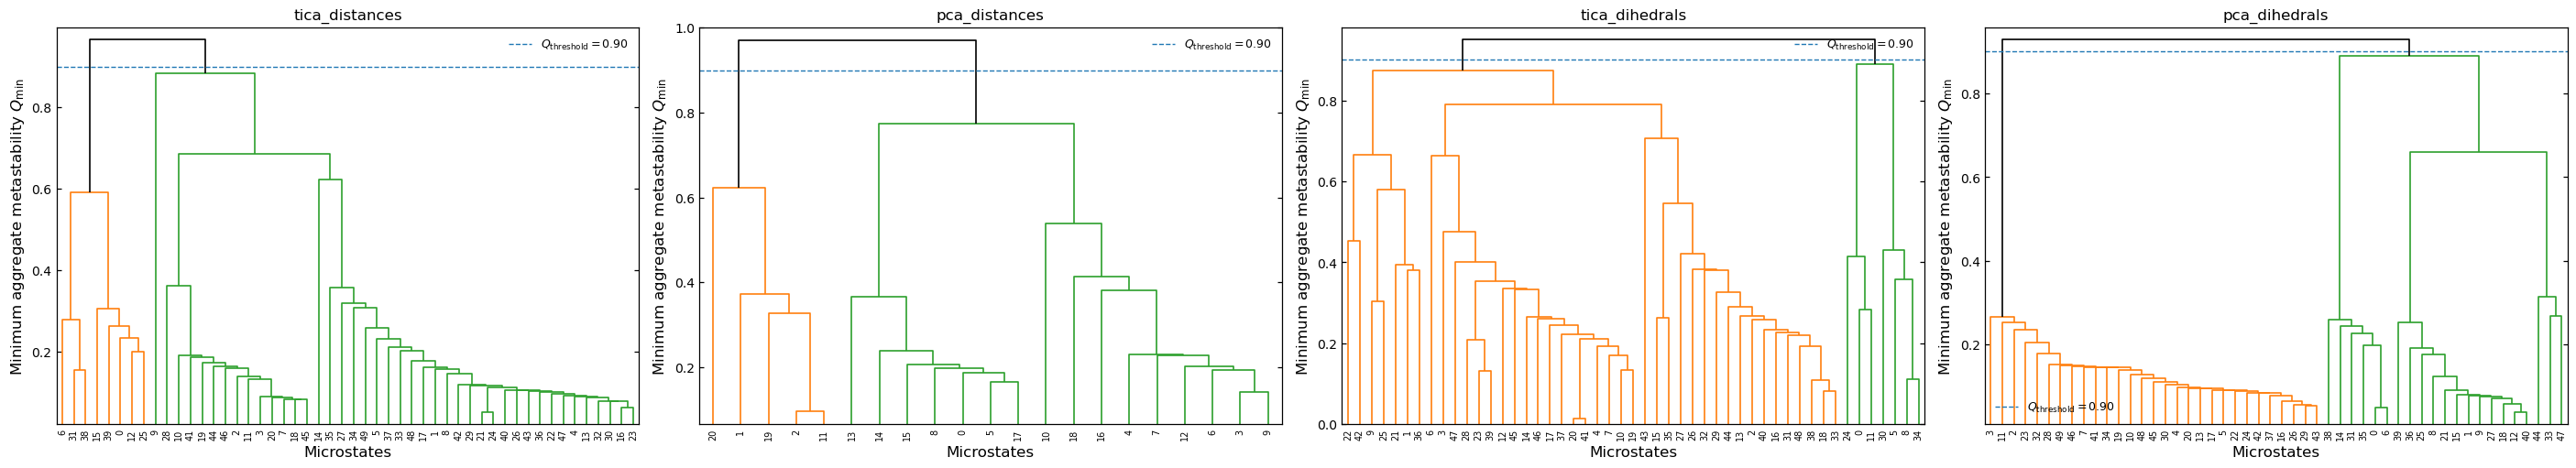

In [7]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(trajectories_labels),
    figsize=(7 * len(trajectories_labels), 5),
    constrained_layout=True,
)

axs = np.atleast_1d(axs)

for ax, name in zip(axs, trajectories_labels):
    plot_metastability_dendrogram(
        metastability_trees[name],
        threshold=Q_THRESHOLD,
        ax=ax,
    )
    ax.set_title(name)

plt.show()